In [1]:
import os

In [2]:
path = "leaf/data"
os.listdir(path)

['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd

In [4]:
# Define the dataset path and create a Path object
dataset = path
image_dir = Path(dataset)

# Collect image file paths for JPG and JPEG formats
filepaths = list(image_dir.glob("**/*.JPG")) + list(image_dir.glob("**/*.JPEG"))

print(len(filepaths))
# Extract labels from the file paths by getting the parent directory name
labels = [x.parent.name for x in filepaths]

# Create a DataFrame with file paths and labels
image_df = pd.DataFrame({
    'filepath': [str(fp) for fp in filepaths],
    'label': labels
})

4188


In [5]:
print(image_df.sample(2),'\n')
print(image_df.info(),'\n')
print(image_df.label.unique(),'\n')
print(image_df['label'].value_counts())
image_df

                                               filepath           label
2874  leaf\data\Gray_Leaf_Spot\Corn_Gray_Spot (480).jpg  Gray_Leaf_Spot
2405   leaf\data\Common_Rust\Corn_Common_Rust (958).JPG     Common_Rust 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4188 entries, 0 to 4187
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filepath  4188 non-null   object
 1   label     4188 non-null   object
dtypes: object(2)
memory usage: 65.6+ KB
None 

['Blight' 'Common_Rust' 'Gray_Leaf_Spot' 'Healthy'] 

label
Common_Rust       1306
Healthy           1162
Blight            1146
Gray_Leaf_Spot     574
Name: count, dtype: int64


,filepath,label
0,leaf\data\Blight\Corn_Blight (1).jpg,Blight
1,leaf\data\Blight\Corn_Blight (10).jpg,Blight
2,leaf\data\Blight\Corn_Blight (100).jpg,Blight
3,leaf\data\Blight\Corn_Blight (1000).JPG,Blight
4,leaf\data\Blight\Corn_Blight (1001).JPG,Blight
...,...,...
4183,leaf\data\Healthy\Corn_Health (996).jpg,Healthy
4184,leaf\data\Healthy\Corn_Health (997).jpg,Healthy
4185,leaf\data\Healthy\Corn_Health (998).jpg,Healthy
4186,leaf\data\Healthy\Corn_Health (999).jpg,Healthy


In [7]:
import matplotlib.pyplot as plt

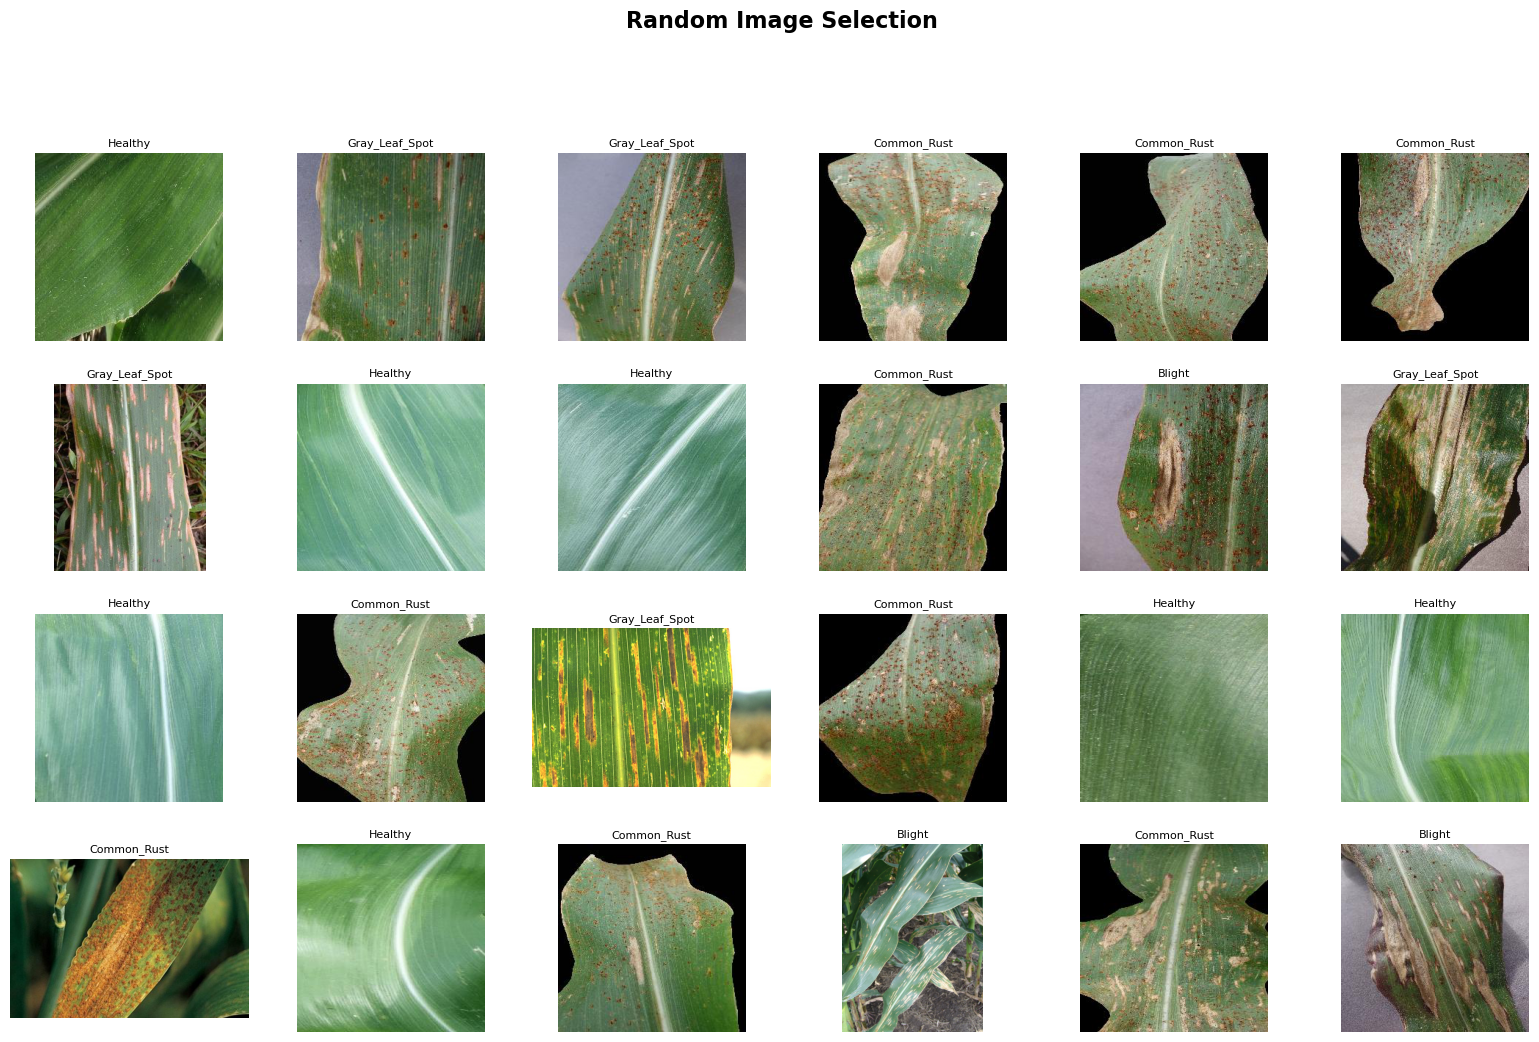

In [8]:
# Select 24 random indices
random_index = np.random.randint(0, len(image_df), 24)

# Create a 4x6 grid of subplots
fig, axes = plt.subplots(nrows=4, ncols=6, figsize=(16, 10))

# Place the randomly selected image and its label in each subplot
for i, ax in enumerate(axes.flat):
    # Get the file path and label for the randomly selected index
    img_path = image_df.filepath.iloc[random_index[i]]
    label = image_df.label.iloc[random_index[i]]

    # Read and display the image
    img = plt.imread(img_path)
    ax.imshow(img)

    # Add a title with a small font and remove the axis lines
    ax.set_title(label, fontsize=8, pad=5)
    ax.axis('off')
# Add a main title for the entire figure
plt.suptitle("Random Image Selection", fontsize=16, fontweight='bold', y=1.05)

# Adjust the layout for better spacing and display the plot
plt.tight_layout(pad=2.0)
plt.show()

In [9]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import Model
import seaborn as sns
from sklearn.model_selection import train_test_split

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

In [11]:
# Data splitting
train_df, test_df = train_test_split(image_df, test_size=0.2, stratify=image_df.label, random_state=42)
print(f"\nTrain shape: {train_df.shape}, Test shape: {test_df.shape}")

# Data generators with augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest",
    validation_split=0.2
)
test_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

# Create data generators
train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=64,
    shuffle=True,
    seed=42,
    subset='training'
)

val_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=64,
    shuffle=True,
    subset='validation'
)

test_gen = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=64,
    shuffle=False
)

# Model configuration
num_classes = len(image_df.label.unique())

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)
base_model.trainable = False  # Freeze base model


Train shape: (3350, 2), Test shape: (838, 2)
Found 2680 validated image filenames belonging to 4 classes.
Found 670 validated image filenames belonging to 4 classes.
Found 838 validated image filenames belonging to 4 classes.


In [12]:
# Custom head
inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

# Model compilation
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,046,212 (11.62 MB)

 Trainable params: 788,228 (3.01 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [13]:
# Callbacks
checkpoint = ModelCheckpoint(
    'best_model.weights.h5',
    save_weights_only=True,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [14]:
# Model training
history = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=[checkpoint, early_stop],
    verbose=1
)

Epoch 1/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 119s 3s/step - accuracy: 0.4357 - loss: 1.4053 - precision: 0.4795 - recall: 0.2912 - val_accuracy: 0.8134 - val_loss: 0.4908 - val_precision: 0.8887 - val_recall: 0.7507
Epoch 2/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.7555 - loss: 0.6290 - precision: 0.8207 - recall: 0.6906 - val_accuracy: 0.8343 - val_loss: 0.3644 - val_precision: 0.8540 - val_recall: 0.8119
Epoch 3/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.8115 - loss: 0.4802 - precision: 0.8368 - recall: 0.7704 - val_accuracy: 0.8746 - val_loss: 0.2981 - val_precision: 0.8932 - val_recall: 0.8493
Epoch 4/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.8445 - loss: 0.4107 - precision: 0.8700 - recall: 0.8097 - val_accuracy: 0.8866 - val_loss: 0.2711 - val_precision: 0.9058 - val_recall: 0.8612
Epoch 5/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.8561 - loss: 0.3601 - precision: 0.8803 - recall: 0.8396 - val_accuracy: 0.9000 - val_loss: 0.2578 - va

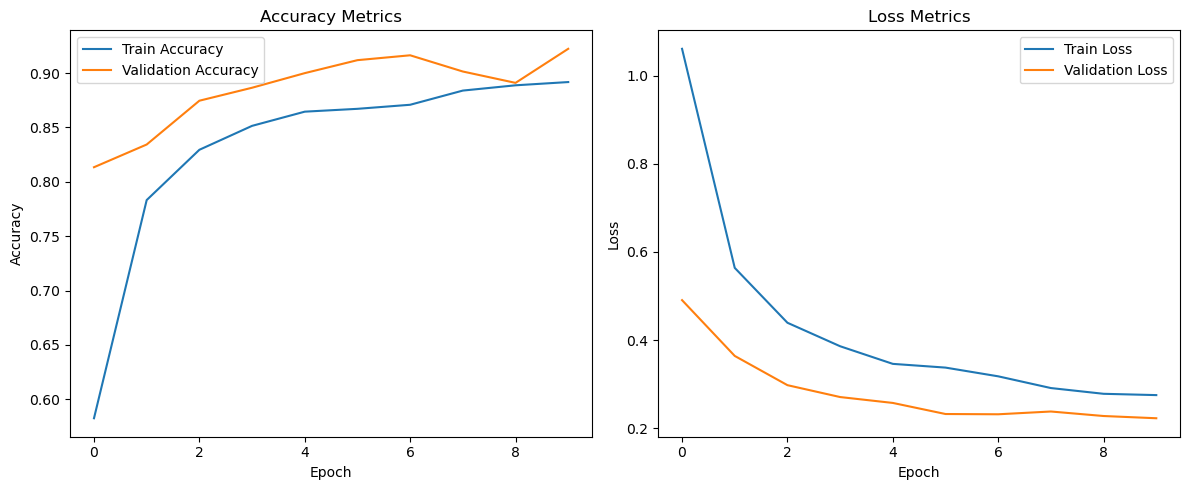

In [15]:
# Training visualization
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Metrics')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Metrics')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# Model evaluation
test_results = model.evaluate(test_gen, verbose=0)
print(f"\nTest Loss: {test_results[0]:.4f}")
print(f"Test Accuracy: {test_results[1]:.4f}")
print(f"Test Precision: {test_results[2]:.4f}")
print(f"Test Recall: {test_results[3]:.4f}")

# Predictions and classification report
y_true = test_gen.classes
y_pred = model.predict(test_gen).argmax(axis=1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=test_gen.class_indices.keys()))



Test Loss: 0.2113
Test Accuracy: 0.9165
Test Precision: 0.9311
Test Recall: 0.9033
14/14 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step

Classification Report:
                precision    recall  f1-score   support

        Blight       0.88      0.83      0.86       229
   Common_Rust       0.95      0.98      0.97       261
Gray_Leaf_Spot       0.76      0.78      0.77       115
       Healthy       0.98      0.99      0.99       233

      accuracy                           0.92       838
     macro avg       0.90      0.90      0.90       838
  weighted avg       0.92      0.92      0.92       838



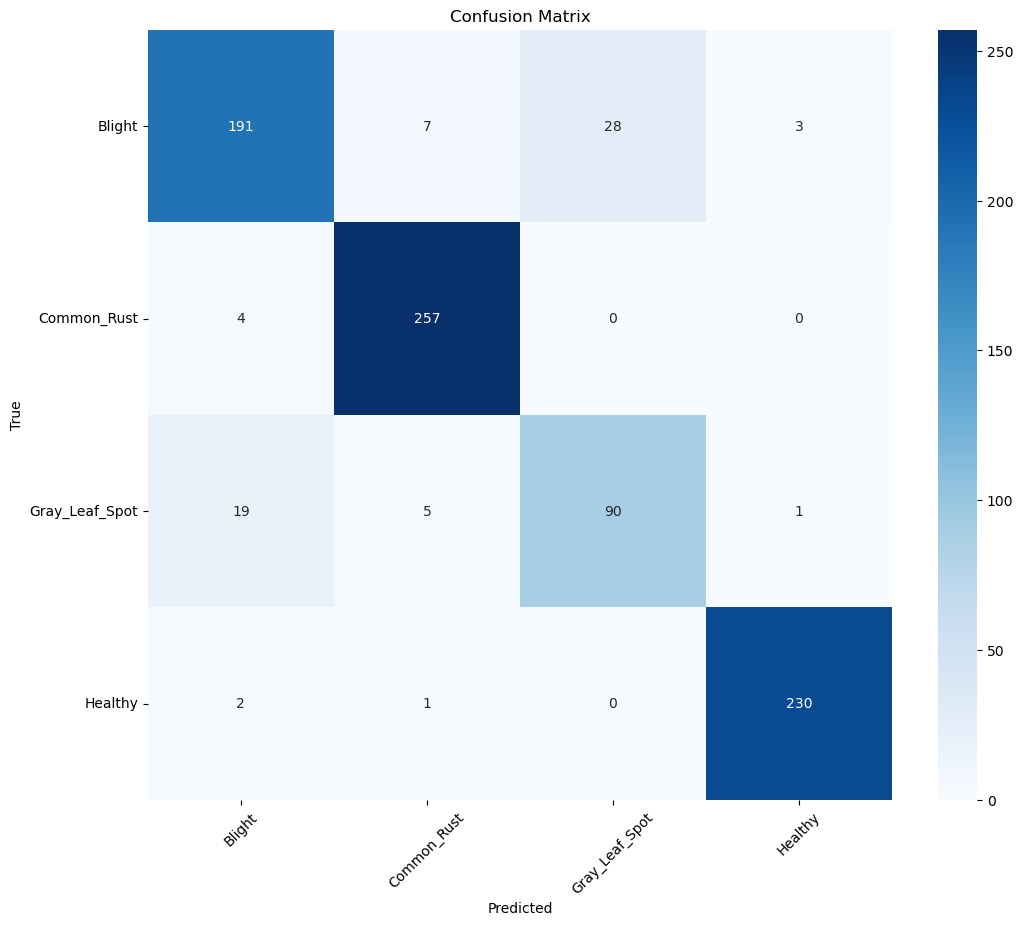

In [17]:
# Confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(confusion_matrix(y_true, y_pred), 
            annot=True, fmt='d', 
            xticklabels=test_gen.class_indices.keys(),
            yticklabels=test_gen.class_indices.keys(),
            cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

In [18]:
model.save("corn_maize2.keras")

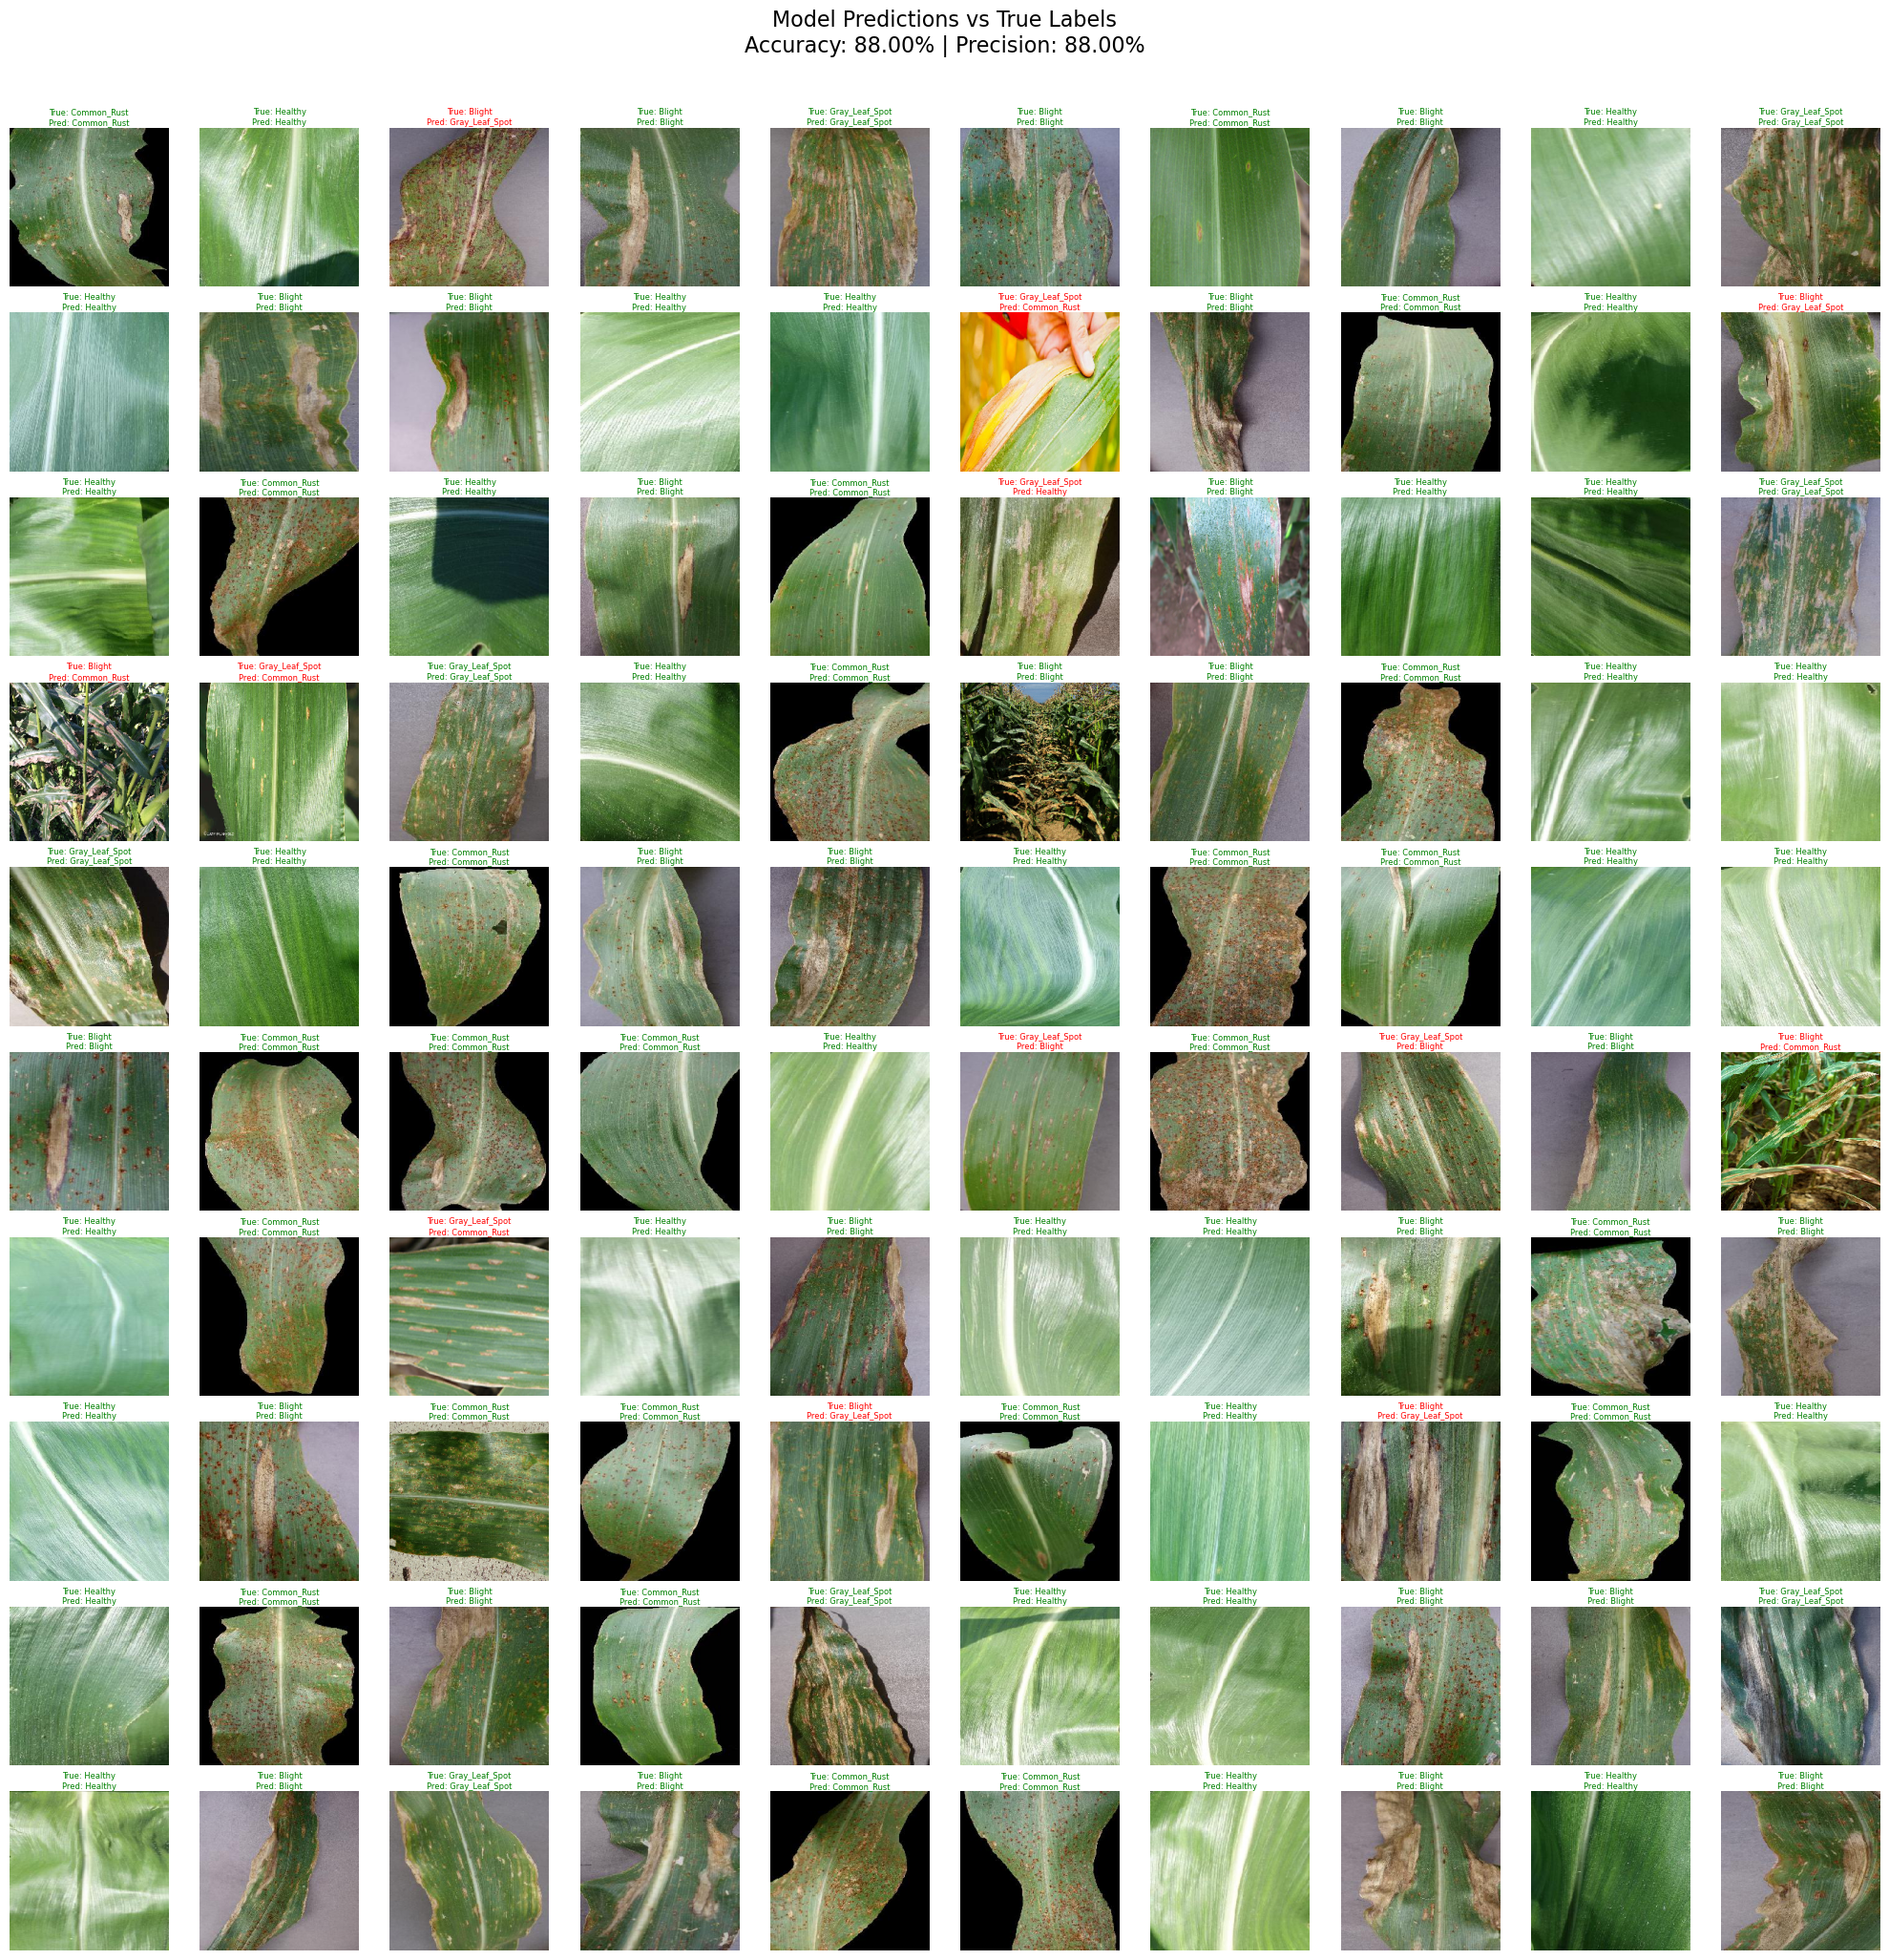

In [19]:
# Reverse the class_indices dictionary to map indices back to class names
class_indices = test_gen.class_indices
class_indices_reverse = {v: k for k, v in class_indices.items()}

# Select 100 random samples from the test dataset
random_indices = np.random.choice(len(test_df), 100, replace=False)
test_samples = test_df.iloc[random_indices]

# Initialize counters for correct predictions
correct_predictions = 0
total_predictions = len(test_samples)
# Create a 10x10 grid for visualization
plt.figure(figsize=(20, 20))
for i, (idx, row) in enumerate(test_samples.iterrows()):
    # Read and preprocess the image
    img = tf.keras.preprocessing.image.load_img(row['filepath'], target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

    # Make a prediction
    pred = model.predict(img_array, verbose=0)
    pred_label = class_indices_reverse[np.argmax(pred)]  # Get predicted label
    true_label = row['label']  # Get true label

    # Check if the prediction is correct
    if pred_label == true_label:
        correct_predictions += 1

    # Plot the image with predicted and true labels
    plt.subplot(10, 10, i + 1)
    plt.imshow(img)
    plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=6, 
              color='green' if pred_label == true_label else 'red', pad=2)
    plt.axis('off')

# Calculate accuracy and precision
accuracy = (correct_predictions / total_predictions) * 100
precision = (correct_predictions / total_predictions) * 100  # Assuming binary classification

# Add a main title with accuracy and precision
plt.suptitle(
    f"Model Predictions vs True Labels\nAccuracy: {accuracy:.2f}% | Precision: {precision:.2f}%", 
    fontsize=16, y=1.02
)

# Adjust layout to reduce spacing
plt.tight_layout(pad=0.5)
plt.show()


In [1]:
### EFFICIENT-NET

In [2]:
data_dir  = "leaf/data"

In [3]:
import tensorflow as tf

In [4]:
IMAGE_SHAPE = (224,224)
BATCH_SIZE= 32

train_data = tf.keras.preprocessing.image_dataset_from_directory(data_dir , image_size = IMAGE_SHAPE , batch_size = BATCH_SIZE , label_mode = "categorical" , 
                                                                validation_split = 0.2 , subset = "training" , seed = 42)

test_data = tf.keras.preprocessing.image_dataset_from_directory(data_dir , image_size = IMAGE_SHAPE , batch_size = BATCH_SIZE , label_mode = "categorical" , 
                                                                validation_split = 0.2 , subset = "validation" , seed = 42)


Found 4188 files belonging to 4 classes.
Using 3351 files for training.
Found 4188 files belonging to 4 classes.
Using 837 files for validation.


base model efficientNet

In [6]:
from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(include_top = False)

Data Augmentation Layer

In [7]:
from tensorflow.keras import layers

In [8]:

data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomHeight(0.2),
    layers.RandomWidth(0.2),
])

In [11]:
input_shape = (224,224,3)

base_model.trainable = False


inputs = tf.keras.layers.Input(shape = input_shape)

x = data_aug(inputs)

x = base_model(x , training = False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

outputs = tf.keras.layers.Dense(4 , activation = "softmax")(x)

model = tf.keras.Model(inputs , outputs)

model.compile(loss = "categorical_crossentropy",
              optimizer = tf.keras.optimizers.Adam(),
              metrics = ["accuracy"])

history = model.fit(train_data , 
                    epochs = 5 ,
                    steps_per_epoch = len(train_data),
                    validation_data = test_data,
                    validation_steps = int(0.25 * len(test_data))
                    )

Epoch 1/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 120s 946ms/step - accuracy: 0.7407 - loss: 0.7358 - val_accuracy: 0.8958 - val_loss: 0.3410
Epoch 2/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 94s 894ms/step - accuracy: 0.9023 - loss: 0.2903 - val_accuracy: 0.9219 - val_loss: 0.2143
Epoch 3/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 90s 858ms/step - accuracy: 0.9169 - loss: 0.2327 - val_accuracy: 0.9271 - val_loss: 0.2112
Epoch 4/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 96s 917ms/step - accuracy: 0.9254 - loss: 0.2086 - val_accuracy: 0.9167 - val_loss: 0.2357
Epoch 5/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 100s 949ms/step - accuracy: 0.9367 - loss: 0.1826 - val_accuracy: 0.9271 - val_loss: 0.2019


In [14]:
import matplotlib.pyplot as plt

In [15]:
import seaborn as sns
sns.set_style("darkgrid")

def plot_model(history):
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    accuracy = history.history["accuracy"]
    val_accuracy = history.history["val_accuracy"]
    
    epochs = len(loss)
    
    fig,axes = plt.subplots(nrows = 2, ncols=1 , figsize = (8,8))
    axes[0].plot(accuracy , label = "training accuracy")
    axes[0].plot(val_accuracy , label = "validation accuracy")
    
    axes[1].plot(loss , label = "training loss")
    axes[1].plot(val_loss , label = "validation loss")
    
    axes[0].legend()
    axes[1].legend()
    
    plt.xlabel("epochs")
    
    axes[0].set_title("Accuracy")
    axes[1].set_title("Loss")
    
    plt.show()

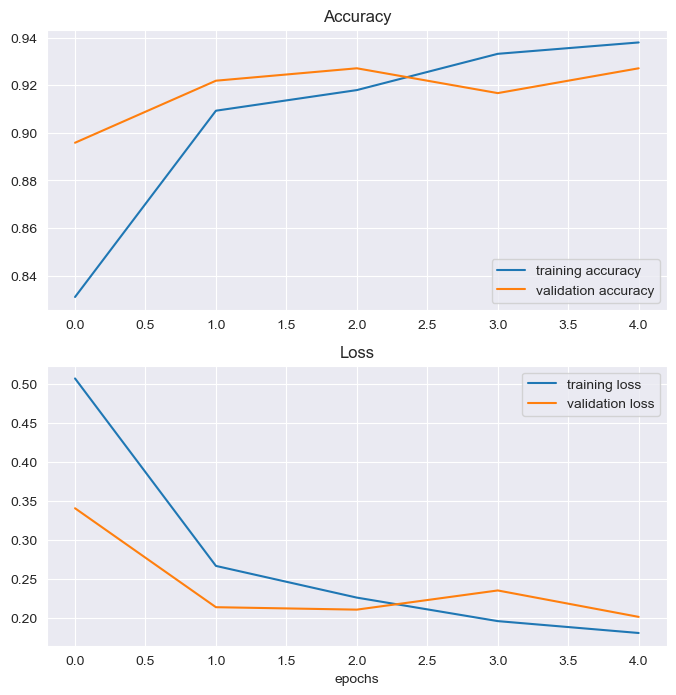

In [16]:
plot_model(history)

fine tuning -continue

In [17]:
base_model.trainable = True

for layer in base_model.layers[:-10]:
    layer.trainable = False
    
model.compile(loss = "categorical_crossentropy",
              optimizer = tf.keras.optimizers.Adam(learning_rate = 0.0001),
              metrics = ["accuracy"])

In [18]:
len(model.trainable_variables)

12

In [19]:
initial_epoch = 5
fine_tuning_epoch = initial_epoch + 5

history_finetuned = model.fit(train_data,
                              epochs = fine_tuning_epoch,
                              validation_data = test_data,
                              validation_steps = int(0.25 * len(test_data)),
                              initial_epoch = history.epoch[-1])

Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.9136 - loss: 0.2339 - val_accuracy: 0.9479 - val_loss: 0.1272
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.9418 - loss: 0.1662 - val_accuracy: 0.9375 - val_loss: 0.1513
Epoch 7/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accuracy: 0.9427 - loss: 0.1492 - val_accuracy: 0.9479 - val_loss: 0.1298
Epoch 8/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.9469 - loss: 0.1394 - val_accuracy: 0.9583 - val_loss: 0.1275
Epoch 9/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.9516 - loss: 0.1224 - val_accuracy: 0.9531 - val_loss: 0.1063
Epoch 10/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.9588 - loss: 0.1120 - val_accuracy: 0.9635 - val_loss: 0.1102


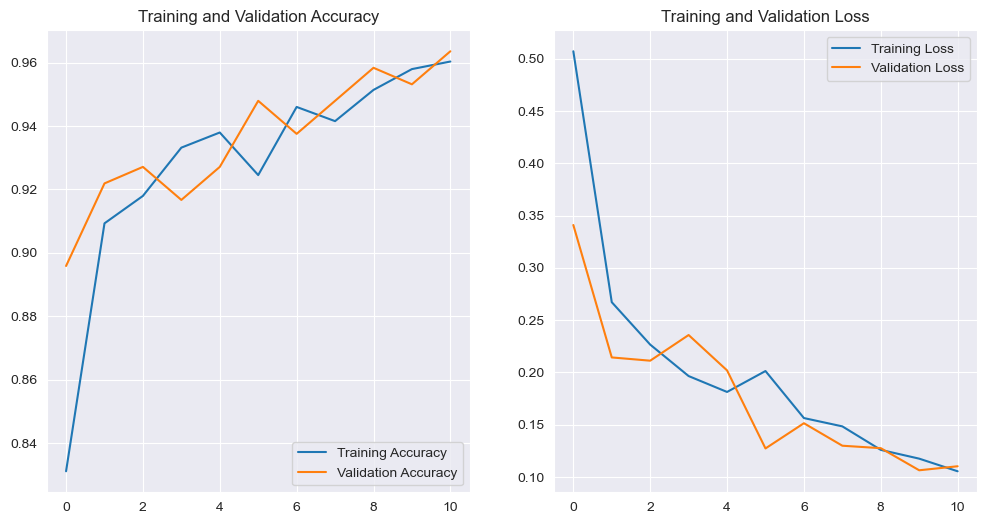

In [20]:

# Combine previous and fine-tuned history
acc = history.history['accuracy'] + history_finetuned.history['accuracy']
val_acc = history.history['val_accuracy'] + history_finetuned.history['val_accuracy']

loss = history.history['loss'] + history_finetuned.history['loss']
val_loss = history.history['val_loss'] + history_finetuned.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [21]:
model.evaluate(test_data)

27/27 ━━━━━━━━━━━━━━━━━━━━ 23s 840ms/step - accuracy: 0.9536 - loss: 0.1183


[0.13366977870464325, 0.9498208165168762]